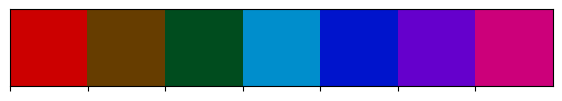

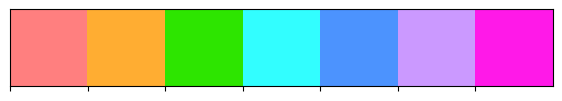

In [1]:
import os
import sys
import torch
import numpy as np
import gymnasium as gym
import random
import matplotlib.pylab as plt

SCRIPT_DIR = os.path.dirname(os.path.abspath("..src"))
sys.path.append(os.path.dirname(SCRIPT_DIR))
from src.policy_analysis import discount_episode_reward, sum_ep_timesteps
from src.plant_watering_env import PlantsWateringEnv
from src.wrappers.env_wrappers import WallObs, WindowViewObs
from src.wrappers.monitor_wrappers import BinaryMonitor, RoomMonitor

In [19]:
grid_size = [6, 6]
n_mdp_actions = 6
window_size = 7
dryness = 0.1
gamma = 0.99
n_seeds = 5
goal_reward = 1
ep_window = 10
timesteps_freq = int(5e5)
plot_mean = True
main_dir = "../general_models/Plants/reward_model/6_6/dry_{}/room/window_{}/q_lr_0.0001/reward_lr_0.001/".format(dryness, window_size)

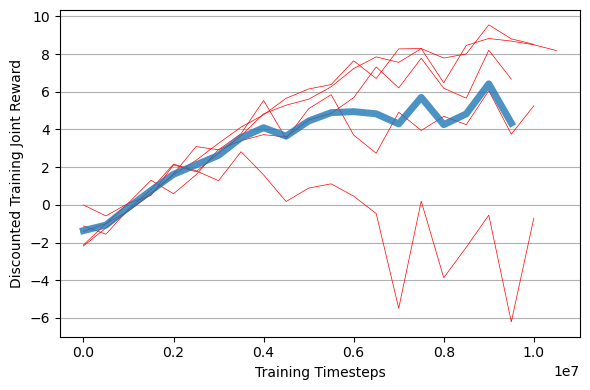

In [20]:
fig = plt.figure(figsize=(6, 4))
max_x_axis = 0
seeds_y_axis = []
for seed in range(n_seeds):
    train_reward = np.load(main_dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()]
    ep_reward, ep_length = discount_episode_reward(train_reward, gamma=gamma)
    ep_timesteps_sum = sum_ep_timesteps(ep_length)
    x_axis = np.arange(ep_length[0], int(ep_timesteps_sum[-1]), timesteps_freq)
    max_x_axis = np.max(x_axis) if np.max(x_axis) > max_x_axis else max_x_axis
    y_axis = []
    count = 0
    for timestep in range(int(ep_length[0]), int(ep_timesteps_sum[-1]), timesteps_freq):
        ind = np.where(ep_timesteps_sum > timestep)[0][0]
        value = np.mean(ep_reward[ind - ep_window: ind]) if ind > ep_window else ep_reward[ind]
        y_axis.append(value)
        count += 1
    plt.plot(x_axis, y_axis, lw=0.5 if plot_mean else 2, label="seed={}".format(seed), c="r")
    seeds_y_axis.append(y_axis)
if plot_mean:
    lenghts = [len(l) for l in seeds_y_axis]
    np.save(main_dir + "/training_reward_mean_over_seeds.npy", np.mean(np.array([l[:min(lenghts)] for l in seeds_y_axis]), 0))
    plt.plot(x_axis[:min(lenghts)], np.mean(np.array([l[:min(lenghts)] for l in seeds_y_axis]), 0), lw=5, alpha=0.8)
plt.xlabel("Training Timesteps")
plt.ylabel("Discounted Training Joint Reward")
plt.grid(axis="y")
# plt.ylim(-200, 1)
# plt.xlim(2e6, )
# plt.legend()
plt.tight_layout()
fig.savefig(main_dir + "/training_curve_ep_window_{}_all_seeds.png".format(ep_window), dpi=300) 

In [ ]:
np.load(main_dir + "evaluation_joint_reward_0.npy", allow_pickle=True)[()]

In [6]:
len(np.load(main_dir + "training_joint_reward_{}.npy".format(seed), allow_pickle=True)[()])

90001

In [6]:
checkpoint = 15

log_file = main_dir + "checkpoints_{}".format(checkpoint)
reward_loss = np.load(log_file + "/reward_model_loss_{}.npy".format(seed))
q_loss = np.load(log_file + "/q_network_loss_{}.npy".format(seed))
reward_model = torch.load(log_file + "/reward_model_{}".format(seed), map_location=torch.device("mps:0"))
q_model = torch.load(log_file + "/q_network_{}".format(seed), map_location=torch.device("mps:0"))

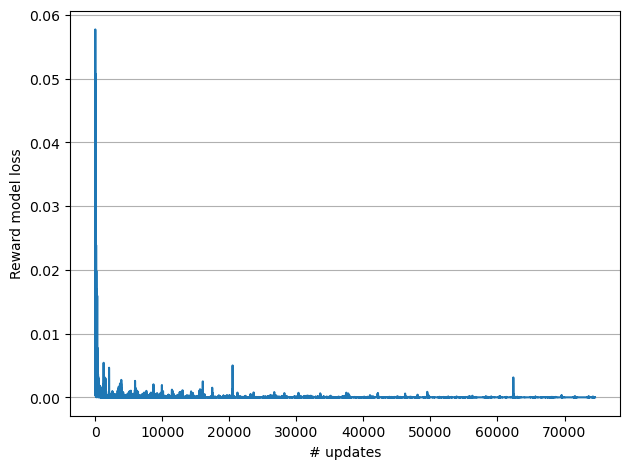

In [7]:
plt.plot(reward_loss)
plt.xlabel("# updates")
plt.ylabel("Reward model loss")
plt.grid(axis="y")
plt.tight_layout()

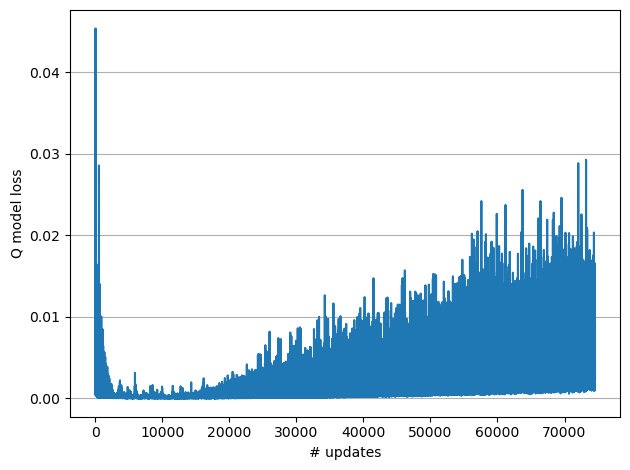

In [8]:
plt.plot(q_loss)
plt.xlabel("# updates")
plt.ylabel("Q model loss")
plt.grid(axis="y")
plt.tight_layout()

In [18]:
DEVICE = "mps:0"
env = gym.make("gym_monitor/Plants-Watering-v1", grid_size=grid_size,
    n_plants=3,
    plants_dryness_prob=dryness,
    dry_difference=0.5,
    agent_start_pos=None,
    max_episode_steps=100,
    render_mode="human",)
# env = PlantsWateringEnv(
#     grid_size=grid_size,
#     n_plants=3,
#     plants_dryness_prob=0.1,
#     dry_difference=0.5,
#     agent_start_pos=[0,0],
#     max_episode_steps=100,
# )
env = WallObs(env, grid_size=grid_size, n_walls=3)
env = WindowViewObs(env, window_size=window_size)
env = RoomMonitor(env, full_monitor=False, monitor_cost=0.0)
# env = BinaryMonitor(env, full_monitor=False, monitor_cost=0.2)

def select_action(q_values) -> int:
    """Choose an action from a Q value distribution/ break ties to a random action"""
    indices = np.argwhere(q_values == np.max(q_values))
    return random.choice(indices)[0]

/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/envs/registration.py:787: UserWarning: WARN: The environment is being initialised with render_mode='human' that is not in the possible render_modes ([]).
  logger.warn(
/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:29: UserWarning: WARN: It seems a Box observation space is an image but the `dtype` is not `np.uint8`, actual type: float64. If the Box observation space is not an image, we recommend flattening the observation to have only a 1D vector.
  logger.warn(
/Users/montaser/miniconda3/envs/mmdp/lib/python3.11/site-packages/gymnasium/utils/passive_env_checker.py:34: UserWarning: WARN: It seems a Box observation space is an image but the lower and upper bounds are not [0, 255]. Actual lower bound: 0.0, upper bound: 3.0. Generally, CNN policies assume observations are within that range, so you may encounter an issue if the observation values are not.
 

In [19]:
# p = 12
# print(s["mdp"][0])
# print("reward", reward_model(s["mdp"].unsqueeze(0)))
# print("q values", q_model(s["mdp"].unsqueeze(0)))

In [ ]:
ep_reward = []
for i in range(10):
    s, info = env.reset()
    # print("s", s["mdp"])
    total_r, timestep = 0, 0
    done = False
    actions, mdp_s = [], []
    env.render()
    while not done:
        mdp_s.append(s["mdp"])
        # with torch.no_grad():
        #     mdp_obs = torch.tensor(s["mdp"], dtype=torch.float32, device=DEVICE).unsqueeze(0)
        #     mon_obs = torch.tensor([s["monitor"]], dtype=torch.float32, device=DEVICE).unsqueeze(0)
        #     q_values = q_model(mdp_obs, mon_obs)
        # action = select_action(q_values.cpu().numpy().squeeze())  # q_values.max(1).indices.view(1, 1).item()
        action = env.action_space.sample()
        actions.append(action)
        # s, r, done, _, info = env.step({"mdp": action % n_mdp_actions, "monitor": action // n_mdp_actions})
        s, r, done, _, info = env.step(action)
        reward = info["mdp_reward"] + r["monitor"]
        total_r += reward * (gamma**timestep)
        timestep += 1
        env.render()
    ep_reward.append(total_r)

In [25]:
env.get_agent_pos(), env.get_grid()[0], s["monitor"], s["mdp"], action, r

(array([2, 5]),
 array([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]]),
 0,
 array([[[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [1., 0., 0., 0., 0., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 1., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0

In [ ]:
ep_reward

In [32]:
p = 17
np.squeeze(mdp_s)[p, 0], actions[p] %n_mdp_actions, actions[p] // n_mdp_actions , np.squeeze(mdp_s)[p + 1, 0]

IndexError: index 17 is out of bounds for axis 0 with size 4

In [91]:
np.squeeze(mdp_s)[p+1, 2]

array([[0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.5, 0. ],
       [0. , 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. ]])

In [20]:
np.round(reward_model(torch.tensor(np.squeeze(mdp_s)[p], dtype=torch.float32, device=DEVICE).unsqueeze(0)).detach().cpu().numpy().squeeze(), 3)

array([ 0.001,  0.001,  0.001,  0.001, -0.196, -0.   ], dtype=float32)

In [9]:
torch.tensor(s["mdp"], dtype=torch.float32, device=DEVICE).unsqueeze(0)

tensor([[[[0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 1., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.]],

         [[0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0., 1., 0.]],

         [[0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 0.],
          [0., 0., 0., 0., 0., 0., 1.],
          [0., 0., 0., 0., 0., 1., 0.]],

         [[1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 1., 1., 1., 1.],
          [1., 1., 1., 0., 0., 0., 0.],
          [1., 1., 1., 0., 0., 0.,

([1, 4],
 array([[0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0.]]),
 0)

In [11]:
s

{'mdp': array([[[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 1., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]],
 
        [[0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0.]],
 
        [[1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 1., 1., 1., 1.],
         [1., 1., 1., 0., 0., 0., 0.],
         

In [15]:
env.get_agent_pos()[1] < 3

True